# Day 13 — Displacement Risk Score: Putting It All Together

---

## What you're building

A **displacement risk score** — a single number per zip code that combines multiple signals to estimate how much pressure a neighborhood is under. Organizations like the Urban Displacement Project, HPD, and community land trusts use composite scores like this to prioritize where to intervene.

Your score will combine four ingredients you've already built:

| Ingredient | Source | Signal |
|---|---|---|
| Median sale price per unit | ACRIS + PLUTO (Day 10) | Investment pressure |
| 311 response time | 311 data (Day 12) | Service quality / city attention |
| Built FAR vs allowed FAR | PLUTO (Walk 07 preview) | Development pressure |
| Median asking rent proxy | Derived from cap rate assumptions | Affordability pressure |

## New concept: normalization

You can't add a sale price ($400,000) to a response time (7 days) — they're different units on different scales. Normalization converts each variable to a common 0–1 scale so they're comparable.

**Min-max normalization:** the lowest value in a column becomes 0, the highest becomes 1, everything else scales in between.

```
normalized = (value - min) / (max - min)
```

Math analogy: converting test scores to percentile ranks. A raw score of 87 means nothing until you know the range. A percentile of 0.92 means something universal — near the top.

In pandas:
```python
df['col_norm'] = (df['col'] - df['col'].min()) / (df['col'].max() - df['col'].min())
```

## Organization rules
- One task per cell.
- Every normalization step gets a sanity check (min should be 0.0, max should be 1.0).
- The final score is a model — document your assumptions.

In [14]:
# CELL 1 — Imports only.
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# CELL 2 — Rebuild ingredient 1: median price per unit by zip code.
#
# Load acris_bushwick_clean.csv and pluto.csv.
df_sales = pd.read_csv('../data/acris_bushwick_clean.csv')
df_pluto = pd.read_csv('../data/pluto.csv')
# Merge on BOROUGH_x + BLOCK + LOT (same as Day 10).
df_merged = pd.merge(
    df_sales, df_pluto,
    left_on=['BOROUGH_x', 'BLOCK', 'LOT'],
    right_on=['borocode', 'Tax block', 'Tax lot']  # adjust to whatever that print shows
)

print(list(df_merged.columns))
print(df_merged['community board'].dtype)
df_merged['unitsres'] = pd.to_numeric(df_merged['unitsres'], errors='coerce')

# Filter to community board 304, unitsres 1-99.
df_residential = df_merged[
    (df_merged['community board'] == 304) &
    (df_merged['unitsres'] > 0) & 
    (df_merged['unitsres'] < 100) 
    ].copy()






# Calculate price_per_unit = DOC. AMOUNT / unitsres.
df_residential['price_per_unit'] = df_residential['DOC. AMOUNT'] / df_residential['unitsres']
# Group by postcode, get median price_per_unit.
df_price_by_zip = df_residential.groupby('postcode')['price_per_unit'].median()
print(df_price_by_zip)

# Store as df_price_by_zip with columns: postcode, median_price_per_unit.
#
# Sanity check: print df_price_by_zip
# (small — only a few Bushwick zip codes)
#
# TODO


/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_87329/3449108008.py:5: DtypeWarning: Columns (0: zonedist3, 1: zonedist4, 2: overlay2, 3: spdist1, 4: spdist2, 5: ltdheight, 6: splitzone, 7: unitsres, 8: unitstotal, 9: lotfront, 10: lotdepth, 11: bldgfront, 12: bldgdepth, 13: irrlotcode, 14: histdist, 15: landmark, 16: condono, 17: edesignum, 18: dcpedited, 19: mihopt1, 20: mihopt2, 21: mihopt3, 22: mihopt4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pluto = pd.read_csv('../data/pluto.csv')


['DOCUMENT ID', 'RECORD TYPE_x', 'BOROUGH_x', 'BLOCK', 'LOT', 'EASEMENT', 'PARTIAL LOT', 'AIR RIGHTS', 'SUBTERRANEAN RIGHTS', 'PROPERTY TYPE', 'STREET NUMBER', 'STREET NAME', 'UNIT', 'GOOD THROUGH DATE_x', 'RECORD TYPE_y', 'CRFN', 'BOROUGH_y', 'DOC. TYPE', 'DOC. DATE', 'DOC. AMOUNT', 'RECORDED / FILED', 'MODIFIED DATE', 'REEL YEAR', 'REEL NBR', 'REEL PAGE', '% TRANSFERRED', 'GOOD THROUGH DATE_y', 'SALE_YEAR', 'borough', 'Tax block', 'Tax lot', 'community board', 'census tract 2010', 'cb2010', 'schooldist', 'council district', 'postcode', 'firecomp', 'policeprct', 'healtharea', 'sanitboro', 'sanitsub', 'address', 'zonedist1', 'zonedist2', 'zonedist3', 'zonedist4', 'overlay1', 'overlay2', 'spdist1', 'spdist2', 'spdist3', 'ltdheight', 'splitzone', 'bldgclass', 'landuse', 'easements', 'ownertype', 'ownername', 'lotarea', 'bldgarea', 'comarea', 'resarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'factryarea', 'otherarea', 'areasource', 'numbldgs', 'numfloors', 'unitsres', 'uni

In [92]:
# CELL 3 — Rebuild ingredient 2: median 311 response time by zip code.
#
# Load your 311 CSV with usecols (same columns as Day 12).
df_311 = pd.read_csv("../data/311_cleaned.csv", usecols=['Created Date', 'Closed Date', 'Incident Zip', 'Problem (formerly Complaint Type)', 'Borough'])

print(df_311.shape)
# Filter to Brooklyn, parse dates, calculate Response Days.
df_brooklyn = df_311[df_311['Borough'] == 'BROOKLYN']

df_brooklyn['Created Date'] = pd.to_datetime(df_brooklyn['Created Date'])
df_brooklyn['Closed Date'] = pd.to_datetime(df_brooklyn['Closed Date'])

df_brooklyn['Response Hours'] = (
    df_brooklyn['Closed Date'] - df_brooklyn['Created Date']
).dt.total_seconds() / 3600

df_brooklyn = df_brooklyn[df_brooklyn['Response Hours'] > 0]


print(df_brooklyn['Response Hours'].describe())
# Filter to Bushwick zips (11221, 11237, 11207).
df_bushwick_311 = df_brooklyn[df_brooklyn['Incident Zip'].isin([11221.0, 11237.0, 11207.0, 11206])]


# Group by Incident Zip, get median Response Days.
df_311_by_zip = df_bushwick_311.groupby('Incident Zip')['Response Hours'].median()
print(df_311_by_zip)


# Store as df_311_by_zip with columns: zip, median_response_days.
#
# Sanity check: print df_311_by_zip
#
# TODO


(106402, 5)


/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_87329/3165418476.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_brooklyn['Created Date'] = pd.to_datetime(df_brooklyn['Created Date'])


count    92401.000000
mean        47.846296
std        101.770142
min          0.000278
25%          0.962222
50%          3.720833
75%         41.046111
max        839.931389
Name: Response Hours, dtype: float64
Incident Zip
11206.0    2.095000
11207.0    7.901667
11221.0    4.599444
11237.0    2.166111
Name: Response Hours, dtype: float64


In [102]:
# CELL 4 — Rebuild ingredient 3: FAR gap by zip code.
#
# Load pluto.csv, filter to community board 304.
df_pluto = pd.read_csv('../data/pluto.csv', usecols=['community board', 'postcode', 'builtfar', 'residfar'])

pluto_bushwick = df_pluto[df_pluto['community board'] == 304.0].copy()

pluto_bushwick['builtfar'] = pd.to_numeric(pluto_bushwick['builtfar'], errors='coerce')
pluto_bushwick['residfar'] = pd.to_numeric(pluto_bushwick['residfar'], errors='coerce')

pluto_bushwick = pluto_bushwick[pluto_bushwick['residfar'] > 0]

pluto_bushwick['far_gap'] = (pluto_bushwick['residfar'] - pluto_bushwick['builtfar']).clip(lower=0)

df_far_by_zip = pluto_bushwick.groupby('postcode')['far_gap'].median()
print(df_far_by_zip)

# Watch out: builtfar and residfar may need pd.to_numeric() first.
# Watch out: manufacturing zones have residfar = 0 — exclude rows where residfar == 0.
#
# Sanity check: print df_far_by_zip
#
# TODO


postcode
11206.0    0.795
11207.0    0.930
11221.0    0.940
11237.0    0.630
Name: far_gap, dtype: float64


**Before moving on — answer these:**
- What does a high FAR gap mean in plain English? Is a high gap a sign of risk or opportunity — or both?
- Why do we exclude rows where residfar == 0?
- At this point you have three separate DataFrames, each indexed by zip code. What operation joins them into one?

A high FAR gap means the building is missing a lot of space that could be used for housing. Depending on the property and the dispalcement risk this could be a growing oppurtunity for more residential units to be added, or if the building is in poor shape or maybe marred by other issues then additional hounsing may not be needed. 

Because they may be negative value or overbuilt or the FAR is built exactly where it needs to be a good sign of housing prosperity given the requirements. 

Merge would allow me to combine all three data frames into one indexed by zip code. 

In [ ]:
# CELL 5 — Merge all three ingredients on zip code.
#
# The shared key across all three DataFrames is zip code.
# Check the column names first — they may be 'postcode', 'Incident Zip', 
# Rename them to a common name before merging, or use left_on/right_on.

price = df_price_by_zip.reset_index()                         # cols: postcode, price_per_unit
price.columns = ['zip', 'price_per_unit']

response = df_311_by_zip.reset_index()                        # cols: Incident Zip, Response Hours
response.columns = ['zip', 'response_hours']

far = df_far_by_zip.reset_index()                             # cols: postcode, far_gap
far.columns = ['zip', 'far_gap']

#
# Use how='inner' — only keep zips that appear in all three datasets.
# Store as df_risk.

df_risk = price.merge(response, on='zip').merge(far, on='zip')

print(df_risk)


#
# Sanity check: print df_risk.shape and df_risk
#
# TODO


       zip  price_per_unit  response_hours  far_gap
0  11207.0   270000.000000        7.901667     0.93
1  11221.0   213750.000000        4.599444     0.94
2  11237.0   191666.666667        2.166111     0.63
(3, 4)


In [128]:
# CELL 6 — Normalize each ingredient to 0-1 scale.
#
# Formula: normalized = (value - min) / (max - min)
#
# Apply to each of the three columns:
#   price_norm     — higher price = higher risk
df_risk['price_norm'] = (
    (df_risk['price_per_unit'] - df_risk['price_per_unit'].min()) /
    (df_risk['price_per_unit'].max() - df_risk['price_per_unit'].min())
)

#   response_norm  — SLOWER response (higher days) = higher risk
#                    (invert: response_norm = 1 - normalized response)
df_risk['response_norm'] = (
    (df_risk['response_hours'] - df_risk['response_hours'].min()) / 
    (df_risk['response_hours'].max() - df_risk['response_hours'].min())
)
#   far_norm       — higher FAR gap = higher development pressure

df_risk['far_norm'] = (
    (df_risk['far_gap'] - df_risk['far_gap'].min()) / (df_risk['far_gap'].max() - df_risk['far_gap'].min())
)
#
# Sanity check: each normalized column should have min=0.0 and max=1.0
# print(df_risk[['price_norm','response_norm','far_norm']].describe())

print(df_risk[['price_norm','response_norm','far_norm']].describe())
# TODO


       price_norm  response_norm  far_norm
count    3.000000       3.000000  3.000000
mean     0.427305       0.474751  0.655914
std      0.515610       0.501909  0.568267
min      0.000000       0.000000  0.000000
25%      0.140957       0.212127  0.483871
50%      0.281915       0.424254  0.967742
75%      0.640957       0.712127  0.983871
max      1.000000       1.000000  1.000000


**Critical thinking pause:**
- Why do we invert the response time normalization?
- Each ingredient is weighted equally right now (1/3 each). Is that the right assumption? What if sale price matters twice as much as FAR gap?
- What ingredients are missing from this score that would make it more accurate?

For the first one i'd actually need some more context on that

I dont think that's the right assumption I think the type of responses that are resolved and how quick, also the sale price matters or could matter more maybe we add a multiplier based on a certain parameter. The far gap could be justified as well to show if the FAR gap is high then displacement would happen faster but also depending on a sale price but i do think these things being wighted differently could be a lot more dynamic in the creation of this

I think things like demographics and crime data are givens as things that could be added. Also how about proximity to transit, and amount of employment in an area this could be fleshed out some more

In [ ]:
# CELL 7 — Compute the displacement risk score.
## Equal weights (current):

#df_risk['risk_score'] = (df_risk['price_norm'] + df_risk['response_norm'] + df_risk['far_norm']) / 3
# Your idea — price counts double:
df_risk['risk_score'] = (2*df_risk['price_norm'] + 1*df_risk['response_norm'] + 1*df_risk['far_norm']) / 4


# Simple equal-weight average of the three normalized columns:
#   risk_score = (price_norm + response_norm + far_norm) / 3
#
df_risk = df_risk.sort_values('risk_score', ascending=False)
print(df_risk[['zip', 'price_norm', 'response_norm', 'far_norm', 'risk_score']])



# Sort by risk_score descending.
# Print the result.
#
# TODO


       zip  price_norm  response_norm  far_norm  risk_score
0  11207.0    1.000000       1.000000  0.967742    0.494624
1  11221.0    0.281915       0.424254  1.000000    0.276454
2  11237.0    0.000000       0.000000  0.000000    0.000000


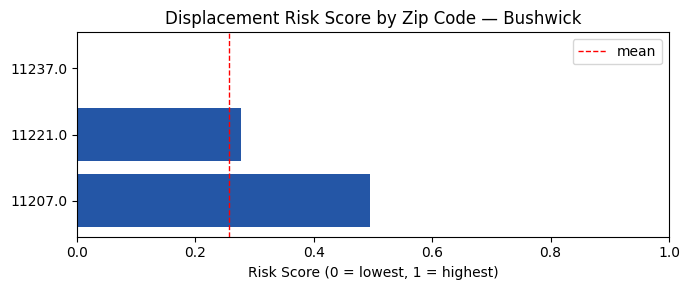

In [150]:
# CELL 8 — Visualize the risk score.
# Plot a horizontal bar chart of risk_score by zip code.
# Add a vertical line at the mean score: plt.axvline(df_risk['risk_score'].mean())
# Title: 'Displacement Risk Score by Zip Code — Bushwick'
# X label: 'Risk Score (0 = lowest, 1 = highest)'
fig, ax = plt.subplots(figsize=(7, 3))

ax.barh(df_risk['zip'].astype(str), df_risk['risk_score'], color='#2456A6')
ax.axvline(df_risk['risk_score'].mean(), color='red', linestyle='--', linewidth=1, label='mean')

ax.set_title('Displacement Risk Score by Zip Code — Bushwick')
ax.set_xlabel('Risk Score (0 = lowest, 1 = highest)')
ax.set_xlim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

# TODO


**Critical thinking pause:**
- Which zip code scores highest? Does that match what you know about those streets?
- This score treats all three ingredients as equally important. If you were a community land trust deciding where to acquire buildings, would you change the weights? How?
- What's the most important thing this score is NOT capturing?

*(Write your answers here)*

11207 scores the highest and honestly yes i can see that a lot of east bushwick and east new york are defintely being priced up a long with an under built amount of housing relative to what it could be causing the price per unit to be high as well

Yes I would weigh sale price much higher, the only type of people who can acquire are higher income, but those sale price could be higher because of the FAR gap on housing. Higher income individuals/segments it seems looking through the data have higher response times than other similar zipcodes

I think demographic data, rent burdened residents, crime data, access to transit among other things

## Day 13 Recap

| What you did | Why it matters |
|---|---|
| Rebuilt three ingredients from prior days | Real pipelines assemble from reusable components |
| Merged on zip code | One shared key can join very different datasets |
| Min-max normalization | Makes incompatible units comparable |
| Equal-weight composite score | A model with explicit, challengeable assumptions |

### What's coming on Day 14
Interactive maps with Folium — turning your risk score into a shareable map you can open in a browser and embed in a portfolio page. The kind of artifact you can show in an interview.